In [509]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

pd.set_option('display.max_columns', None)

In [510]:
DATA_PATH = '../data/raw/ecommerce-data.csv'

sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_PATH, encoding='unicode_escape')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Phase 1: Data Overview

**Objective:** Establish baseline understanding of dataset size, structure, dtypes, and numeric ranges.

In [511]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nDuplicate columns:", df.columns[df.columns.duplicated()].tolist())
print("\nMemory usage (bytes):", df.memory_usage(deep=True).sum())

Shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Duplicate columns: []

Memory usage (bytes): 181533217


In [512]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [513]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [514]:
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/2011 12:05,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/2011 8:40,9.95,13502.0,United Kingdom


In [515]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [516]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [517]:
print(df[df['Quantity']<=0]['Quantity'].sort_values())

negative_quantity=(df['Quantity']<=0).sum()
print(f'\nNumber of negative value in Quantity feature: {negative_quantity}')

540422   -80995
61624    -74215
225529    -9600
225530    -9600
4287      -9360
          ...  
240697       -1
240696       -1
240694       -1
242447       -1
249284       -1
Name: Quantity, Length: 10624, dtype: int64

Number of negative value in Quantity feature: 10624


In [518]:
display(df[df['UnitPrice']<=0])

negative_quantity=(df['UnitPrice']<=0).sum()
print(f'\nNumber of negative value in UnitPrice feature: {negative_quantity}')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom



Number of negative value in UnitPrice feature: 2517


In [519]:
df.loc[df['UnitPrice'] == 0, 'Description'].unique().tolist()

[nan,
 'amazon',
 '?',
 'ROUND CAKE TIN VINTAGE GREEN',
 'check',
 'damages',
 'CREAM SWEETHEART LETTER RACK',
 'ZINC WILLIE WINKIE  CANDLE STICK',
 'BOX OF 24 COCKTAIL PARASOLS',
 'DOORMAT ENGLISH ROSE ',
 'DOORMAT 3 SMILEY CATS',
 'GREEN REGENCY TEACUP AND SAUCER',
 'FRENCH BLUE METAL DOOR SIGN 7',
 'FRENCH BLUE METAL DOOR SIGN 5',
 'FRENCH BLUE METAL DOOR SIGN 6',
 'FRENCH BLUE METAL DOOR SIGN 4',
 'FRENCH BLUE METAL DOOR SIGN No',
 'FRENCH BLUE METAL DOOR SIGN 8',
 'FRENCH BLUE METAL DOOR SIGN 1',
 'RED KITCHEN SCALES',
 'IVORY KITCHEN SCALES',
 'SET OF 6 SOLDIER SKITTLES',
 'CHILDS GARDEN TROWEL BLUE ',
 'CHILDRENS GARDEN GLOVES BLUE',
 'PICNIC BASKET WICKER SMALL',
 'PICNIC BASKET WICKER LARGE',
 'EMPIRE UNION JACK TV DINNER TRAY',
 'TV DINNER TRAY VINTAGE PAISLEY',
 'SPACEBOY TV DINNER TRAY',
 'TV DINNER TRAY DOLLY GIRL',
 'CHILDS GARDEN SPADE BLUE',
 'CHILDS GARDEN RAKE BLUE',
 'WATERING CAN PINK BUNNY',
 'ENAMEL FIRE BUCKET CREAM',
 'ENAMEL FLOWER JUG CREAM',
 'AIRLINE BAG VIN

In [520]:
df['Quantity'].median()

np.float64(3.0)

In [521]:
df['Quantity'].quantile([0.75,0.8,0.85,0.9,0.95,0.97,0.99])

0.75     10.0
0.80     12.0
0.85     12.0
0.90     24.0
0.95     29.0
0.97     48.0
0.99    100.0
Name: Quantity, dtype: float64

In [522]:
multi_price_codes = df.groupby('StockCode')['UnitPrice'].nunique()
multi_price_codes = multi_price_codes[multi_price_codes > 1].index

zero_price_codes = df[df['UnitPrice'] == 0]['StockCode'].unique()

target_codes = set(multi_price_codes).intersection(set(zero_price_codes))

df[df['StockCode'].isin(target_codes)].groupby('StockCode')['UnitPrice'].unique()

StockCode
10002                                     [0.85, 1.66, 1.63, 0.0]
10080                                           [0.85, 0.39, 0.0]
10123C                                                [0.65, 0.0]
10133             [0.85, 1.66, 0.42, 0.81, 0.79, 1.63, 0.83, 0.0]
15030                                                 [0.29, 0.0]
                                      ...                        
PADS                                                 [0.001, 0.0]
POST            [18.0, 15.0, 40.0, 28.0, 4.41, 12.34, 3.5, 5.7...
gift_0001_10                                          [8.33, 0.0]
gift_0001_20                                  [17.02, 16.67, 0.0]
gift_0001_30                                   [25.53, 25.0, 0.0]
Name: UnitPrice, Length: 1287, dtype: object

## Observation about numeric feature

### Observation
- 'CustomerID' feature contain a lot of null value
- 'Quantity' varies significantly, however, mostly under 10 (~75%). There may be some outlier in this feature
- There are some negative value in Quantity feature, our first assumption is it is a typo mistake. 
- Unit price also varies, but at a lesser extent. It contains lots of zero value and some negative value. It contain some outlier so we consider proceed it like 'Quantity' feature
- 'CustomerID' feature contain a lot of null value, but it will be discussed deeply in the next part. 

### Action
- We consider scaling it or cutting it off in term of outlier in 'Quantity' feature.
- In 'Quantity' column, considering take absolute value of non negative number or droping them since it is only account for nearly **2%** of the dataset
- We may consider filling rows with non-positive number in 'UnitPrice' with mode with the same 'Stockcode' since the mode is likely the listed price of that product. After that, we might dropping the rest row contain non-positive value because it account for a really small percentage (<1%) of the dataset and it possibly have meaningless description, according to our analyst.

In [523]:
df.describe(include='object')

/var/folders/jq/lmmm4rbd3qd2d1f1lbjl0fl40000gn/T/ipykernel_92051/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [524]:
df.groupby('StockCode')['Description'].unique()[df.groupby('StockCode')['Description'].nunique() > 1]

StockCode
10080                      [GROOVY CACTUS INFLATABLE, nan, check]
10133                     [COLOURING PENCILS BROWN TUBE, damaged]
15058A             [BLUE POLKADOT GARDEN PARASOL, nan, wet/rusty]
15058C               [ICE CREAM DESIGN GARDEN PARASOL, wet/rusty]
16008                [SMALL FOLDING SCISSOR(POINTED EDGE), check]
                                      ...                        
90195A                          [PURPLE GEMSTONE BRACELET, check]
90210D                     [PURPLE ACRYLIC FACETED BANGLE, check]
DCGS0003                              [BOXED GLASS ASHTRAY, ebay]
DCGS0069                            [OOH LA LA DOGS COLLAR, ebay]
gift_0001_20    [Dotcomgiftshop Gift Voucher £20.00, to push o...
Name: Description, Length: 650, dtype: object

In [525]:
df['Country'].unique().tolist()

['United Kingdom',
 'France',
 'Australia',
 'Netherlands',
 'Germany',
 'Norway',
 'EIRE',
 'Switzerland',
 'Spain',
 'Poland',
 'Portugal',
 'Italy',
 'Belgium',
 'Lithuania',
 'Japan',
 'Iceland',
 'Channel Islands',
 'Denmark',
 'Cyprus',
 'Sweden',
 'Austria',
 'Israel',
 'Finland',
 'Bahrain',
 'Greece',
 'Hong Kong',
 'Singapore',
 'Lebanon',
 'United Arab Emirates',
 'Saudi Arabia',
 'Czech Republic',
 'Canada',
 'Unspecified',
 'Brazil',
 'USA',
 'European Community',
 'Malta',
 'RSA']

In [526]:
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


### Observation about non-numeric feature
- Description contain a few null value
- 'InvoiceNo' and 'StockCode' are currently in string type, which should be integer type
- 'InvoiceDate' is in string type, which should be DateTime type
- 'Country' feature contain quite a few country

### Action
- Parse 'InvoiceDate into DateTime type
- Considering feature engineering a 'Continent' from 'Country'
- Filling null value in 'Description' feature based on 'StockCode'. The remaining null might be dropped because the number of them is small, which do not affecting too much our dataset


## 2 - Data Cleaning
**Objective:** Quantify data quality issues and produce a clean analysis-ready DataFrame.

In [527]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct
Description,1454,0.27
CustomerID,135080,24.93


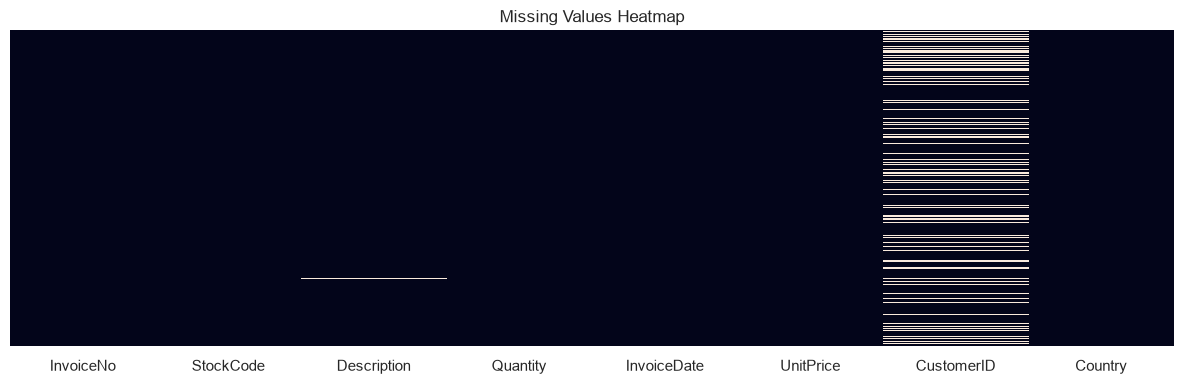

In [528]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [529]:
print("Full-row duplicates:", df.duplicated().sum())
print("Duplicate IDs:", df.duplicated(subset='CustomerID').sum())

Full-row duplicates: 5268
Duplicate IDs: 537536


In [530]:
#Checking duplicate id
all_duplicates = df[df.duplicated(keep=False)]
display(all_duplicates.sort_values(by=['InvoiceNo', 'StockCode']).head(10))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [531]:
#Dropping duplicate value
print(f"Initial shape: {df.shape}")

df.drop_duplicates(keep='first', inplace=True)

print(f"Shape after dropping null values: {df.shape}")

Initial shape: (541909, 8)
Shape after dropping null values: (536641, 8)


In [532]:
#Dropping non-positive value in 'Quantity' feature
print(f"Before cleaning: {df.shape}")

df = df[df['Quantity'] > 0]

print(f"After cleaning: {df.shape}")

Before cleaning: (536641, 8)
After cleaning: (526054, 8)


In [533]:
#Filling UnitPrice based on StockCode and dropping remaining non-positive value

print("Row with UnitPrice <= 0 before processing:", (df['UnitPrice'] <= 0).sum())

df.loc[df['UnitPrice'] <= 0, 'UnitPrice'] = np.nan
get_mode = lambda x: x.mode()[0] if not x.mode().empty else np.nan

df['UnitPrice'] = df['UnitPrice'].fillna(
    df.groupby('StockCode')['UnitPrice'].transform(get_mode)
)

print("Number of rows with UnitPrice <= 0 after processing:", (df['UnitPrice'] <= 0).sum())
print("Number of remaining null row:", df['UnitPrice'].isnull().sum())

#Dropping remaining null row
df=df[df['UnitPrice']>0]
print("Number of remaining null row after second cleaning:", df['UnitPrice'].isnull().sum())

Row with UnitPrice <= 0 before processing: 1176
Number of rows with UnitPrice <= 0 after processing: 0
Number of remaining null row: 19
Number of remaining null row after second cleaning: 0


In [534]:
#Parse InvoiceDate into DateTime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [535]:
#Filling Description based on StockCode feature
desc_mapping = df.dropna(subset=['Description']).drop_duplicates('StockCode').set_index('StockCode')['Description']
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_mapping))

df.dropna(subset=['Description'], inplace=True)

In [538]:
df.info()

df.head()

<class 'pandas.DataFrame'>
Index: 526035 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    526035 non-null  str           
 1   StockCode    526035 non-null  str           
 2   Description  526035 non-null  str           
 3   Quantity     526035 non-null  int64         
 4   InvoiceDate  526035 non-null  datetime64[us]
 5   UnitPrice    526035 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      526035 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.1 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Phase 3: Final Pre-RFM Cleanup

**Objective:** Prepare the dataset for customer-level aggregation by removing rows that can't contribute to segmentation.

**Actions:**
- Drop rows with null `CustomerID` — can't segment anonymous customers
- Cast `CustomerID` to `int` (currently `float64` due to NaN)
- Remove cancellation invoices (`InvoiceNo` starting with `C`) — these are returns, not purchases
- Create `TotalPrice = Quantity × UnitPrice` — building block for Monetary

In [ ]:
# Drop rows with null CustomerID — can't segment anonymous customers
print(f"Before dropping null CustomerID: {df.shape}")
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
print(f"After dropping null CustomerID: {df.shape}")

# Remove cancellation invoices (InvoiceNo starting with 'C')
cancellation_count = df['InvoiceNo'].str.startswith('C').sum()
print(f"\nCancellation invoices found: {cancellation_count}")
df = df[~df['InvoiceNo'].str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# Create TotalPrice = Quantity × UnitPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"\nFinal transaction-level dataset: {df.shape}")
df.head()

## Phase 4: RFM Feature Engineering (Preview)

**Objective:** Transform transaction-level data into customer-level RFM features for analysis.

**RFM Framework:**
- **Recency** — Days since last purchase (lower = more engaged)
- **Frequency** — Number of distinct orders (higher = more loyal)
- **Monetary** — Total revenue generated (higher = more valuable)

This is a preview for EDA purposes. The production-ready version will be built in `02_feature_engineering.ipynb`.

In [ ]:
# Define reference date as 1 day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date (simulated 'today'): {reference_date}")

# Build RFM table
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape} — one row per customer")
rfm.head(10)

In [ ]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2).T

## Phase 5: Univariate Analysis

**Objective:** Understand the distribution of each RFM feature individually.

**Why this matters for K-Means:**
- K-Means uses **Euclidean distance** and **mean-based centroids**
- Both are sensitive to **skewness** — long tails compress most data into a tiny range, making distance meaningless
- Histograms and box plots give visual evidence to decide whether we need transformations

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    # Histogram + KDE
    sns.histplot(rfm[col], kde=True, ax=axes[0, i], bins=50,
                 color=colors[i], edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Box plot
    sns.boxplot(x=rfm[col], ax=axes[1, i], color=colors[i])
    axes[1, i].set_title(f'{col} — Box Plot', fontsize=13, fontweight='bold')
    axes[1, i].set_xlabel(col)

plt.suptitle('Univariate Analysis of RFM Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics with skewness and kurtosis
summary = rfm[['Recency', 'Frequency', 'Monetary']].describe().T
summary['skew'] = rfm[['Recency', 'Frequency', 'Monetary']].skew()
summary['kurtosis'] = rfm[['Recency', 'Frequency', 'Monetary']].kurtosis()
summary.round(2)

### Observation
- **Recency** is relatively spread out — a mix of recent and inactive customers.
- **Frequency** is heavily right-skewed — most customers ordered only 1-3 times, with a few power-buyers placing dozens of orders.
- **Monetary** is extremely right-skewed — most customers spent modest amounts, but a handful generated thousands in revenue.
- The high skewness in Frequency and Monetary confirms that **outlier treatment and log transformation** will be necessary before K-Means.

## Phase 6: Bivariate & Multivariate Analysis

**Objective:** Understand relationships between RFM features.

**Key questions:**
- Are Frequency and Monetary highly correlated? (If so, K-Means would double-weight that dimension)
- Can we already see natural clusters in the scatter plots?
- What direction are the R↔F and R↔M correlations?

In [ ]:
# Pairplot
sns.pairplot(rfm[['Recency', 'Frequency', 'Monetary']],
             diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 10, 'color': '#3498db'},
             diag_kws={'color': '#e74c3c'})
plt.suptitle('RFM Pairplot', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# Correlation heatmap — Pearson vs Spearman side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

pearson_corr = rfm_features.corr(method='pearson')
spearman_corr = rfm_features.corr(method='spearman')

sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0], square=True, linewidths=1)
axes[0].set_title('Pearson Correlation', fontsize=13, fontweight='bold')

sns.heatmap(spearman_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[1], square=True, linewidths=1)
axes[1].set_title('Spearman Correlation', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Individual scatter plots for each feature pair
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(rfm[x], rfm[y], alpha=0.3, s=10, c='#3498db', edgecolors='none')
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    ax.set_title(f'{x} vs {y}', fontsize=13, fontweight='bold')

plt.suptitle('Bivariate Scatter Plots',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observation
- **Frequency vs Monetary** show a strong positive correlation — customers who order more tend to spend more. If the Pearson correlation is above 0.85, consider engineering **Average Order Value** (M/F) to reduce redundancy.
- **Recency vs Frequency** and **Recency vs Monetary** show negative correlations — more recent customers tend to have higher frequency and spending. This confirms RFM logic: engaged customers buy more.
- **Spearman** correlation is generally higher than **Pearson** for F↔M — this indicates a monotonic but non-linear relationship, typical for skewed data.
- The scatter plots show most data points **concentrated in the bottom-left corner** (low F, low M) with a sparse tail — confirming the heavy right skew.

## Phase 7: Outlier Detection & Treatment

**Objective:** Identify and cap extreme values that would distort K-Means centroids.

**Why capping (winsorization) instead of removal:**
- Removing outliers deletes real customers — a high-spender is still a valid segment member
- Capping reduces their influence while preserving all customers
- K-Means centroids are **means** — a single extreme value can pull a centroid dramatically

**Why IQR method:**
- Non-parametric — doesn't assume the data is normally distributed
- Appropriate for our skewed RFM features where z-score methods would fail

In [ ]:
# Detect outliers using IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((series < lower) | (series > upper)).sum()
    pct = outlier_count / len(series) * 100
    return lower, upper, outlier_count, pct

print("Outlier Detection (IQR Method)")
print("=" * 65)
for col in ['Recency', 'Frequency', 'Monetary']:
    lower, upper, count, pct = detect_outliers_iqr(rfm[col])
    print(f"{col:>12s}: bounds=[{lower:>8.2f}, {upper:>10.2f}], "
          f"outliers={count:>4,} ({pct:.1f}%)")

In [ ]:
# Cap outliers at IQR boundaries (winsorization)
rfm_capped = rfm.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm_capped[col].quantile(0.25)
    Q3 = rfm_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    rfm_capped[col] = rfm_capped[col].clip(lower=lower, upper=upper)

# Before vs After comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x=rfm[col], ax=axes[0, i], color='#e74c3c')
    axes[0, i].set_title(f'{col} — Before Capping',
                         fontsize=12, fontweight='bold')

    sns.boxplot(x=rfm_capped[col], ax=axes[1, i], color='#2ecc71')
    axes[1, i].set_title(f'{col} — After Capping',
                         fontsize=12, fontweight='bold')

plt.suptitle('Outlier Treatment: Before vs After Capping',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Skewness comparison: raw vs capped
print("Skewness Comparison: Raw vs Capped")
print("=" * 45)
print(f"{'Feature':>12s} | {'Raw':>8s} | {'Capped':>8s}")
print("-" * 45)
for col in ['Recency', 'Frequency', 'Monetary']:
    raw_skew = rfm[col].skew()
    capped_skew = rfm_capped[col].skew()
    print(f"{col:>12s} | {raw_skew:>8.2f} | {capped_skew:>8.2f}")

### Observation
- Capping significantly reduced the extreme outliers visible in the box plots.
- Skewness decreased for Frequency and Monetary, but they remain positively skewed — confirming that **log transformation** is still needed.
- Recency had few or no outliers beyond the IQR whiskers, so capping had minimal effect — as expected for a naturally bounded feature.

## Phase 8: Log Transformation Analysis

**Objective:** Evaluate whether log transformation produces more symmetric distributions suitable for K-Means.

**Why log transform:**
- Even after capping, Frequency and Monetary remain right-skewed
- `log1p(x) = log(1+x)` compresses the long right tail and spreads the dense left side
- More symmetric features → Euclidean distance becomes meaningful → better K-Means clusters
- `log1p` instead of `log` because it safely handles zero values

In [ ]:
# Apply log1p transformation to capped RFM features
rfm_log = rfm_capped.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_log[col] = np.log1p(rfm_log[col])

# Compare distributions: capped vs log-transformed
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_capped[col], kde=True, ax=axes[0, i], bins=50,
                 color='#3498db', edgecolor='white')
    axes[0, i].set_title(f'{col} — Capped',
                         fontsize=12, fontweight='bold')

    sns.histplot(rfm_log[col], kde=True, ax=axes[1, i], bins=50,
                 color='#e67e22', edgecolor='white')
    axes[1, i].set_title(f'{col} — Log Transformed',
                         fontsize=12, fontweight='bold')

plt.suptitle('Log Transformation: Before vs After',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Full skewness comparison across all transformation stages
print("Skewness Across All Transformation Stages")
print("=" * 55)
print(f"{'Feature':>12s} | {'Raw':>8s} | {'Capped':>8s} | {'Log':>8s}")
print("-" * 55)
for col in ['Recency', 'Frequency', 'Monetary']:
    raw = rfm[col].skew()
    capped = rfm_capped[col].skew()
    logged = rfm_log[col].skew()
    print(f"{col:>12s} | {raw:>8.2f} | {capped:>8.2f} | {logged:>8.2f}")

### Observation
- Log transformation dramatically reduced skewness for all features, especially Frequency and Monetary.
- The log-transformed distributions are much closer to symmetric/bell-shaped — this is what K-Means needs for Euclidean distance to work properly.
- **Conclusion for feature engineering notebook:** The transformation pipeline should be: Raw → Cap outliers (IQR) → Log transform (`log1p`) → StandardScaler → ready for K-Means.

## EDA Summary & Key Takeaways

### Data Quality
- Started with **541,909 transactions**, cleaned down after removing duplicates, negative quantities, zero prices, null CustomerIDs, and cancellations.
- The final RFM table contains **one row per customer** ready for analysis.

### RFM Feature Characteristics
- All three features are **heavily right-skewed** — typical for e-commerce data.
- **Frequency and Monetary** are positively correlated — customers who order frequently also tend to spend more.
- **Recency** is negatively correlated with F and M — engaged customers order more recently and spend more.

### Transformation Pipeline Decision
Based on this analysis, the feature engineering notebook (`02_feature_engineering.ipynb`) should apply:
1. **IQR capping** — reduce outlier influence on K-Means centroids
2. **Log transformation** (`log1p`) — reduce skewness for meaningful Euclidean distance
3. **StandardScaler** — equalize feature scales so no single feature dominates distance calculations

### Next Steps
→ Proceed to `02_feature_engineering.ipynb` to build the clean, reproducible transformation pipeline.